In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
import yfinance as yf

# 1. Fetch data explicitly turning off auto-adjustment to preserve 'Adj Close'
df = yf.download("NGE", start="2021-01-01", end="2026-01-01", auto_adjust=False)

# 2. Senior Dev Move: Flatten yfinance's new multi-index headers down to simple strings
df.columns = [col[0] for col in df.columns]

# 3. Safely isolate the column and forward-fill missing dates
df = df[['Adj Close']].ffill()

# View the clean pipeline output
print("[SUCCESS] Data cleanly loaded into the pipeline!")
print(df.tail())


[*********************100%***********************]  1 of 1 completed

[SUCCESS] Data cleanly loaded into the pipeline!
            Adj Close
Date                 
2024-03-22       3.74
2024-03-25       3.74
2024-03-26       3.74
2024-03-27       3.74
2024-03-28       3.74


In [3]:
# import yfinance as yf

# # Pull Zenith Bank via its London Stock Exchange global listing
# df = yf.download("0QVM.L", start="2021-01-01", end="2026-01-01", auto_adjust=False)

# # Flatten columns to remove multi-index errors
# df.columns = [col for col in df.columns]

# # Isolate Adjusted Close and fill gaps
# df = df[['Adj Close']].ffill()

# print("[SUCCESS] Living market data retrieved!")
# print("Dataframe Shape:", df.shape)
# print(df.dropna().tail())


In [4]:
# df.to_csv("Stock Analysis.csv")

In [5]:
import yfinance as yf
import pandas as pd

print("[INFO] Initializing stable data pipeline extraction...")

# 1. Download data with auto_adjust=False to preserve raw asset metrics
raw_df = yf.download("AAPL", start="2021-01-01", end="2026-01-01", auto_adjust=False)

# 2. Extract column headers cleanly (handles both Multi-Index and Flat index structures)
if isinstance(raw_df.columns, pd.MultiIndex):
    # Take just the metric name (e.g., 'Adj Close') and discard the ticker level
    raw_df.columns = [col[0] for col in raw_df.columns]
else:
    raw_df.columns = [str(col) for col in raw_df.columns]

# 3. Dynamic Column Fallback: Locate adjusted close, or fallback to standard close if missing
df = pd.DataFrame(index=raw_df.index)
if 'Adj Close' in raw_df.columns:
    df['Adj Close'] = raw_df['Adj Close']
elif 'Close' in raw_df.columns:
    print("[WARNING] 'Adj Close' not found. Falling back to standard 'Close'.")
    df['Adj Close'] = raw_df['Close']
else:
    raise KeyError(f"Could not locate price data. Available columns: {list(raw_df.columns)}")

# 4. Forward fill missing market data gaps (weekends/holidays)
df = df.ffill()

print("\n[SUCCESS] Living market data cleanly loaded into your pipeline!")
print(f"Dataframe Dimensions: {df.shape[0]} trading rows across {df.shape[1]} column.")
print("\n--- Validation Sample (Tail End) ---")
print(df.tail())


[INFO] Initializing stable data pipeline extraction...


[*********************100%***********************]  1 of 1 completed


[SUCCESS] Living market data cleanly loaded into your pipeline!
Dataframe Dimensions: 1255 trading rows across 1 column.

--- Validation Sample (Tail End) ---
             Adj Close
Date                  
2025-12-24  273.302216
2025-12-26  272.892975
2025-12-29  273.252350
2025-12-30  272.573578
2025-12-31  271.355835


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

print("[INFO] Starting Day 2 Statistical Analysis Pipeline...")

# 1. Run the Augmented Dickey-Fuller (ADF) Test on Raw Prices
print("\n--- Running ADF Test on Raw Prices ---")
result_raw = adfuller(df['Adj Close'])
print(f"ADF Statistic: {result_raw[0]:.4f}")
print(f"p-value: {result_raw[1]:.4f}")

# Interpret the p-value
if result_raw[1] <= 0.05:
    print("[RESULT] The raw price data is STATIONARY (p <= 0.05). No differencing needed.")
else:
    print("[RESULT] The raw price data is NON-STATIONARY (p > 0.05). Differencing required.")

# 2. Senior Dev Move: Calculate Log Returns and First Differences
print("\n--- Applying First Differencing (Stationary Transformation) ---")
df['Price_Diff'] = df['Adj Close'].diff()
df['Log_Return'] = df['Adj Close'].pct_change()

# Drop the resulting NaN in row 1 from differencing to prevent statistical crashes
df_clean = df.dropna()

# 3. Re-run the ADF Test on the Differenced Data to confirm success
result_diff = adfuller(df_clean['Price_Diff'])
print(f"Differenced ADF Statistic: {result_diff[0]:.4f}")
print(f"Differenced p-value: {result_diff[1]:.4f}")

if result_diff[1] <= 0.05:
    print("[SUCCESS] Differenced data is perfectly STATIONARY! Ready for modeling.")
else:
    print("[WARNING] Data still non-stationary. Higher-order differencing may be required.")


[INFO] Starting Day 2 Statistical Analysis Pipeline...

--- Running ADF Test on Raw Prices ---
ADF Statistic: -0.7873
p-value: 0.8228
[RESULT] The raw price data is NON-STATIONARY (p > 0.05). Differencing required.

--- Applying First Differencing (Stationary Transformation) ---
Differenced ADF Statistic: -33.8260
Differenced p-value: 0.0000
[SUCCESS] Differenced data is perfectly STATIONARY! Ready for modeling.


In [7]:
df_clean

,Adj Close,Price_Diff,Log_Return
Date,,,
2021-01-05,127.295464,1.554619,0.012364
2021-01-06,123.010521,-4.284943,-0.033661
2021-01-07,127.208054,4.197533,0.034123
2021-01-08,128.306015,1.097961,0.008631
2021-01-11,125.323013,-2.983002,-0.023249
...,...,...,...
2025-12-24,273.302216,1.447296,0.005324
2025-12-26,272.892975,-0.409241,-0.001497
2025-12-29,273.252350,0.359375,0.001317


[INFO] Computing ACF and PACF plots on Stationary Data...
[SUCCESS] Plots generated successfully. Look at your notebook figure output.


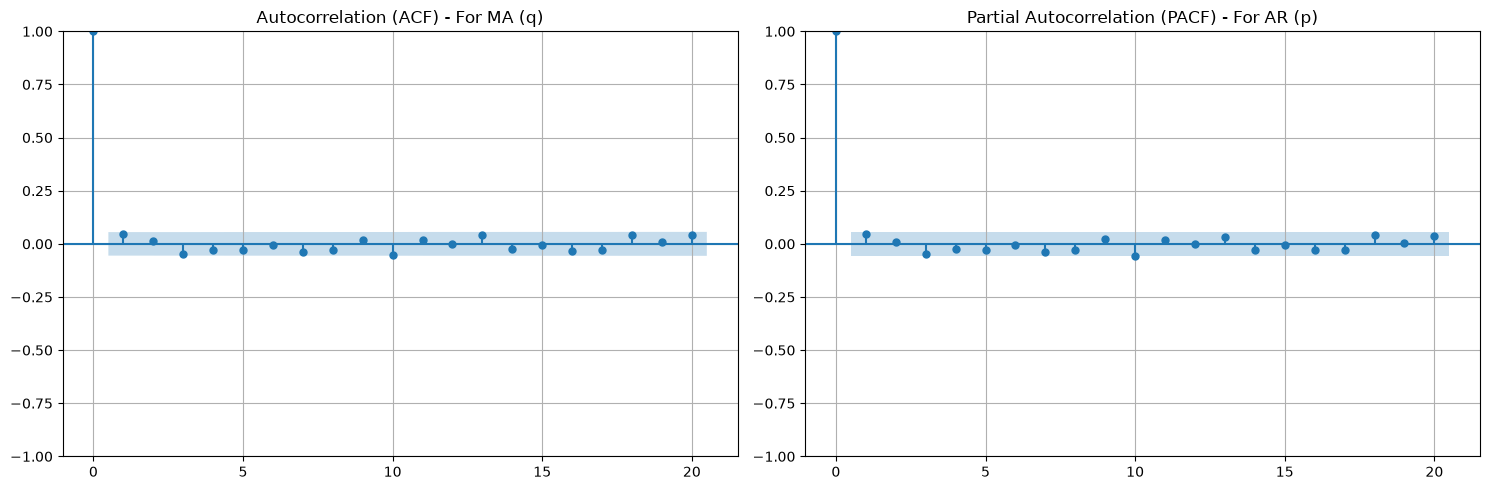

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

print("[INFO] Computing ACF and PACF plots on Stationary Data...")

# Isolate clean stationary differences
stationary_series = df['Price_Diff'].dropna()

# Create a clean side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Autocorrelation Function (ACF) to determine potential 'q' values
sm.graphics.tsa.plot_acf(stationary_series, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) - For MA (q)')
axes[0].grid(True)

# Plot Partial Autocorrelation Function (PACF) to determine potential 'p' values
sm.graphics.tsa.plot_pacf(stationary_series, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) - For AR (p)')
axes[1].grid(True)

plt.tight_layout()
print("[SUCCESS] Plots generated successfully. Look at your notebook figure output.")


In [9]:
import requests
print(requests.get("https://businessday.ng/robots.txt").text)

User-agent: *
Disallow: /wp-login.php
Disallow: /wp-register.php
Disallow: /?s=
Disallow: /search/
Disallow: /dlm_uploads/
Disallow: /*?noamp=mobile&
Disallow: /*?noamp=mobile&*
Disallow: /page/*?amp
Allow: /wp-content/uploads/
Allow: /wp-admin/admin-ajax.php

Sitemap: https://businessday.ng/sitemap_index.xml



In [10]:
from scraper import inspect_page_structure
inspect_page_structure("https://businessday.ng/category/companies/")

[INFO] robots.txt check for https://businessday.ng/category/companies/ -> allowed=True
[INFO] Sleeping 4.7s before requesting https://businessday.ng/category/companies/ (attempt 1/3)


--- Headline candidates (h1/h2/h3), with hrefs where present ---
h2 ['post-title'] Unilever Nigeria to pay N11.5bn dividend to shareholders as profit rises -> https://businessday.ng/companies/article/unilever-nigeria-to-pay-n11-5bn-dividend-to-shareholders-as-profit-rises/
h2 ['post-title'] African Prudential profit rises by 18.1% in H1 on interest income growth -> https://businessday.ng/companies/article/african-prudential-profit-rises-by-18-1-in-h1-on-interest-income-growth/
h2 ['post-title'] Nigerian trio's $60m stake in Thor swells as Segilola gold mine powers cash gene -> https://businessday.ng/companies/article/nigerian-trios-60m-stake-in-thor-swells-as-segilola-gold-mine-powers-cash-generation/
h2 ['post-title'] OPay strengthens fight against digital fraud with AI, smart security tools -> https://businessday.ng/companies/article/opay-strengthens-fight-against-digital-fraud-with-ai-smart-security-tools/
h2 ['post-title'] Africa50 appoints Djalal Khimdjee as CEO of principal inves

In [11]:
from scraper import inspect_page_structure
inspect_page_structure("https://businessday.ng/companies/article/nigerian-trios-60m-stake-in-thor-swells-as-segilola-gold-mine-powers-cash-generation/")

[INFO] robots.txt check for https://businessday.ng/companies/article/nigerian-trios-60m-stake-in-thor-swells-as-segilola-gold-mine-powers-cash-generation/ -> allowed=True
[INFO] Sleeping 4.0s before requesting https://businessday.ng/companies/article/nigerian-trios-60m-stake-in-thor-swells-as-segilola-gold-mine-powers-cash-generation/ (attempt 1/3)


--- Headline candidates (h1/h2/h3), with hrefs where present ---
h1 ['post-title'] Nigerian trio’s $60m stake in Thor swells as Segilola gold mine powers cash gene -> None
h2 None Unilever Nigeria to pay N11.5bn dividend to shareholders as profit rises -> https://businessday.ng/companies/article/unilever-nigeria-to-pay-n11-5bn-dividend-to-shareholders-as-profit-rises/
h2 None African Prudential profit rises by 18.1% in H1 on interest income growth -> https://businessday.ng/companies/article/african-prudential-profit-rises-by-18-1-in-h1-on-interest-income-growth/
h2 None OPay strengthens fight against digital fraud with AI, smart security tools -> https://businessday.ng/companies/article/opay-strengthens-fight-against-digital-fraud-with-ai-smart-security-tools/
h2 None Subscribe to our Newsletters -> None

--- Date candidates: meta tags ---
article:published_time -> 2026-07-22T09:48:15+00:00
article:modified_time -> 2026-07-22T10:35:04+00:00

--- Date candidates: visible tags (time / cl

In [12]:
import importlib
import scraper
importlib.reload(scraper)

<module 'scraper' from 'c:\\Users\\HomePC\\Documents\\Time-Series-Analysis-for-Stock-Market-Prediction-main\\notebook\\scraper.py'>

In [13]:
import importlib
import scraper
importlib.reload(scraper)
news_df = scraper.scrape_ticker_news("FIRSTHOLDCO", max_articles=5)
print(news_df)

[INFO] robots.txt check for https://businessday.ng/category/companies/ -> allowed=True
[INFO] Sleeping 3.2s before requesting https://businessday.ng/category/companies/ (attempt 1/3)
[INFO] Parsed 20 article links from listing page https://businessday.ng/category/companies/
[INFO] robots.txt check for https://businessday.ng/companies/article/unilever-nigeria-to-pay-n11-5bn-dividend-to-shareholders-as-profit-rises/ -> allowed=True
[INFO] Sleeping 5.1s before requesting https://businessday.ng/companies/article/unilever-nigeria-to-pay-n11-5bn-dividend-to-shareholders-as-profit-rises/ (attempt 1/3)
[INFO] robots.txt check for https://businessday.ng/companies/article/african-prudential-profit-rises-by-18-1-in-h1-on-interest-income-growth/ -> allowed=True
[INFO] Sleeping 5.1s before requesting https://businessday.ng/companies/article/african-prudential-profit-rises-by-18-1-in-h1-on-interest-income-growth/ (attempt 1/3)
[INFO] robots.txt check for https://businessday.ng/companies/article/nige

         date       ticker                                           headline  \
0  2026-07-22  FIRSTHOLDCO  Unilever Nigeria to pay N11.5bn dividend to sh...   
1  2026-07-22  FIRSTHOLDCO  African Prudential profit rises by 18.1% in H1...   
2  2026-07-22  FIRSTHOLDCO  Nigerian trio’s $60m stake in Thor swells as S...   
3  2026-07-22  FIRSTHOLDCO  OPay strengthens fight against digital fraud w...   
4  2026-07-21  FIRSTHOLDCO  Africa50 appoints Djalal Khimdjee as CEO of pr...   

                                           body_text  \
0  Unilever Nigeria Plc, a consumer goods firm, h...   
1  African Prudential’s half-year profit after ta...   
2  A group of Nigerian investors led by Segun Law...   
3  OPay, a leading fintech company in Nigeria, is...   
4  Africa50, the specialist investor in African i...   

                                          source_url  
0  https://businessday.ng/companies/article/unile...  
1  https://businessday.ng/companies/article/afric...  
2  https://

In [14]:
print(news_df.loc[0, "date"])
print(len(news_df.loc[0, "body_text"]))
print(news_df.loc[0, "body_text"][:200])

2026-07-22
2071
Unilever Nigeria Plc, a consumer goods firm, has approved to pay its shareholders N11.5 billion in dividend payments at N2 per 50 kobo shares for the first half of 2026 According to the interim divide


In [15]:
import inspect
print(inspect.getsource(scraper.parse_article_page))

def parse_article_page(html: str, article_url: str, ticker: str) -> NewsItem | None:
    """Extract headline, date, and body text from a single article page."""
    soup = BeautifulSoup(html, "html.parser")

    title_tag = soup.find("h1")
    headline = title_tag.get_text(strip=True) if title_tag else None

    # Date: confirmed via inspection that BusinessDay embeds this in a meta tag,
    # not visible markup. Fall back to visible tags only if the meta tag is absent.
    raw_date = None
    meta_date_tag = soup.find("meta", attrs={"property": "article:published_time"})
    if meta_date_tag and meta_date_tag.get("content"):
        raw_date = meta_date_tag["content"]
    else:
        date_tag = soup.select_one(SELECTORS["article_date"])
        if date_tag:
            raw_date = date_tag.get("datetime") or date_tag.get_text(strip=True)

    # Body: strip script/style/ad elements first — confirmed the raw .post-content
    # div mixes ad-tracking markup in with the real article text

In [16]:
import scraper
print(scraper.SELECTORS)

{'listing_headline_link': 'h2.post-title a', 'article_date': 'time, .date-published, .entry-date, .post-date', 'article_body': '.entry-content, article .content, .post-content'}


In [18]:
import scraper
raw_df = scraper.scrape_company_news(max_articles=50, max_pages=3)
tagged_df = scraper.tag_articles_by_ticker(raw_df)
print(tagged_df[["ticker", "mention_scope", "headline"]])

[INFO] robots.txt check for https://businessday.ng/category/companies/ -> allowed=True
[INFO] Sleeping 4.9s before requesting https://businessday.ng/category/companies/ (attempt 1/3)
[INFO] Parsed 20 article links from listing page https://businessday.ng/category/companies/
[INFO] robots.txt check for https://businessday.ng/category/companies/page/2/ -> allowed=True
[INFO] Sleeping 4.4s before requesting https://businessday.ng/category/companies/page/2/ (attempt 1/3)
[WARNING] Non-200 status 403 for https://businessday.ng/category/companies/page/2/
[INFO] Sleeping 5.4s before requesting https://businessday.ng/category/companies/page/2/ (attempt 2/3)
[WARNING] Non-200 status 403 for https://businessday.ng/category/companies/page/2/
[INFO] Sleeping 6.0s before requesting https://businessday.ng/category/companies/page/2/ (attempt 3/3)
[WARNING] Non-200 status 403 for https://businessday.ng/category/companies/page/2/
[ERROR] Giving up on https://businessday.ng/category/companies/page/2/ af

        ticker mention_scope  \
0  FIRSTHOLDCO      headline   
1     WEMABANK     body_only   
2  FIRSTHOLDCO      headline   
3   ACCESSCORP     body_only   
4   ZENITHBANK     body_only   
5  FIRSTHOLDCO      headline   
6   ZENITHBANK     body_only   
7     BUAFOODS      headline   
8   ACCESSCORP      headline   
9   TRANSPOWER      headline   

                                            headline  
0  FirstHoldCo delivers N1.93trn gross earnings, ...  
1  Nigeria’s oldest indigenous bank joins Duplo t...  
2  First HoldCo becomes Nigeria’s most valuable b...  
3  First HoldCo becomes Nigeria’s most valuable b...  
4  First HoldCo becomes Nigeria’s most valuable b...  
5  Otedola raises First HoldCo stake to 20.4% aft...  
6  Otedola raises First HoldCo stake to 20.4% aft...  
7  Khalifa Rabiu earns N13.2bn dividend as BUA Fo...  
8  Access Holdings reduces stake in Ghana subsidi...  
9  Transcorp Power to pay N11.2bn dividend to sha...  


In [19]:
tagged_df

,date,ticker,headline,body_text,source_url,mention_scope
0,2026-07-21,FIRSTHOLDCO,"FirstHoldCo delivers N1.93trn gross earnings, ...",FirstHoldCo PLC has reported another outstandi...,https://businessday.ng/companies/article/first...,headline
1,2026-07-21,WEMABANK,Nigeria’s oldest indigenous bank joins Duplo t...,"Duplo, an African financial operations and pay...",https://businessday.ng/companies/article/niger...,body_only
2,2026-07-20,FIRSTHOLDCO,First HoldCo becomes Nigeria’s most valuable b...,First HoldCo Plc has become Nigeria’s most val...,https://businessday.ng/companies/article/first...,headline
3,2026-07-20,ACCESSCORP,First HoldCo becomes Nigeria’s most valuable b...,First HoldCo Plc has become Nigeria’s most val...,https://businessday.ng/companies/article/first...,body_only
4,2026-07-20,ZENITHBANK,First HoldCo becomes Nigeria’s most valuable b...,First HoldCo Plc has become Nigeria’s most val...,https://businessday.ng/companies/article/first...,body_only
5,2026-07-20,FIRSTHOLDCO,Otedola raises First HoldCo stake to 20.4% aft...,Nigerian billionaire Femi Otedola has tightene...,https://businessday.ng/companies/article/otedo...,headline
6,2026-07-20,ZENITHBANK,Otedola raises First HoldCo stake to 20.4% aft...,Nigerian billionaire Femi Otedola has tightene...,https://businessday.ng/companies/article/otedo...,body_only
7,2026-07-20,BUAFOODS,Khalifa Rabiu earns N13.2bn dividend as BUA Fo...,Nigerian business executive Isyaku Abdulsamad ...,https://businessday.ng/companies/article/khali...,headline
8,2026-07-20,ACCESSCORP,Access Holdings reduces stake in Ghana subsidi...,Access Holdings Plc has reduced its stake in i...,https://businessday.ng/news/article/access-hol...,headline
9,2026-07-20,TRANSPOWER,Transcorp Power to pay N11.2bn dividend to sha...,"Transcorp Power, in the first six months of 20...",https://businessday.ng/companies/article/trans...,headline
